# Baixo Tapajós — conhecendo os dados reais

**Piloto de janeiro de 2024 · preparação para 2001–2024**

Este caderno localiza a região, explica o que foi solicitado ao ERA5, verifica os arquivos
e mostra como as observações horárias da reanálise se transformam em séries diárias.
O estudo considera o ano completo; janeiro é o primeiro teste técnico, não uma escolha
da estação principal nem uma amostra suficiente para caracterizar o clima regional.

As funções auxiliares estão em `src/amazon_chaos`. Aqui ficam os parâmetros, a narrativa,
as operações de exploração e os gráficos. **Executar todas as células não inicia downloads.**
O caderno utiliza somente arquivos locais e sinaliza explicitamente aquisições pendentes.

O ERA5 combina modelo e observações. Seus valores não equivalem a termômetros instalados
em cada quadradinho. Nossa pergunta futura é sobre associações entre o histórico de
perturbação e a dinâmica climática; este piloto verifica primeiro a qualidade da base.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
from IPython.display import Markdown, display

from amazon_chaos.config import load_config
from amazon_chaos.io.era5_monthly import plan_requests, job_directory, open_downloaded
from amazon_chaos.preprocess.daily import derive_hourly, daily_statistics
from amazon_chaos.preprocess.grid import build_grid
from amazon_chaos.pilot_maps import plot_region, load_context

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlelocation': 'left',
                     'font.size': 10, 'axes.grid': False})
ROOT = Path.cwd()
assert (ROOT / 'configs/tapajos_2024.yaml').exists(), 'Abra o kernel na raiz do projeto TCC.'
CFG = load_config(ROOT / 'configs/tapajos_2024.yaml')
START = str(CFG['time']['test_start'])
END = str(CFG['time']['test_end'])
OFFSET = CFG['time']['utc_offset_hours']
FIGURES = ROOT / 'reports/figures/tapajos_2024'
FIGURES.mkdir(parents=True, exist_ok=True)
GRID = build_grid(CFG['spatial']['area'])
CONTEXT = load_context()
display(Markdown(f'**Intervalo desta execução:** {START} a {END}. '
                 f'**Dia local:** UTC{OFFSET:+03d}:00 fixo. **Pontos de grade:** {len(GRID)}.'))

**Intervalo desta execução:** 2024-01-01 a 2024-01-31. **Dia local:** UTC-03:00 fixo. **Pontos de grade:** 56.

## 1. Onde estamos?

O mapa vai do Brasil ao Pará e ao recorte do Baixo Tapajós. O contorno vermelho é a área
do estudo; os pontos azuis são os centros da grade ERA5; a estrela é uma célula escolhida
apenas para demonstrar os cálculos. **Os dados cobrem toda a caixa, não apenas a estrela.**

As malhas municipais IBGE são da edição 2022. As unidades de conservação são limites
atuais consultados no ICMBio/INDE em 2026: servem ao contexto e não reconstituem automaticamente
os limites de 2001 ou 2024. Os rios Natural Earth são generalizados; suas linhas não
permitem calcular a fração de água de cada célula.

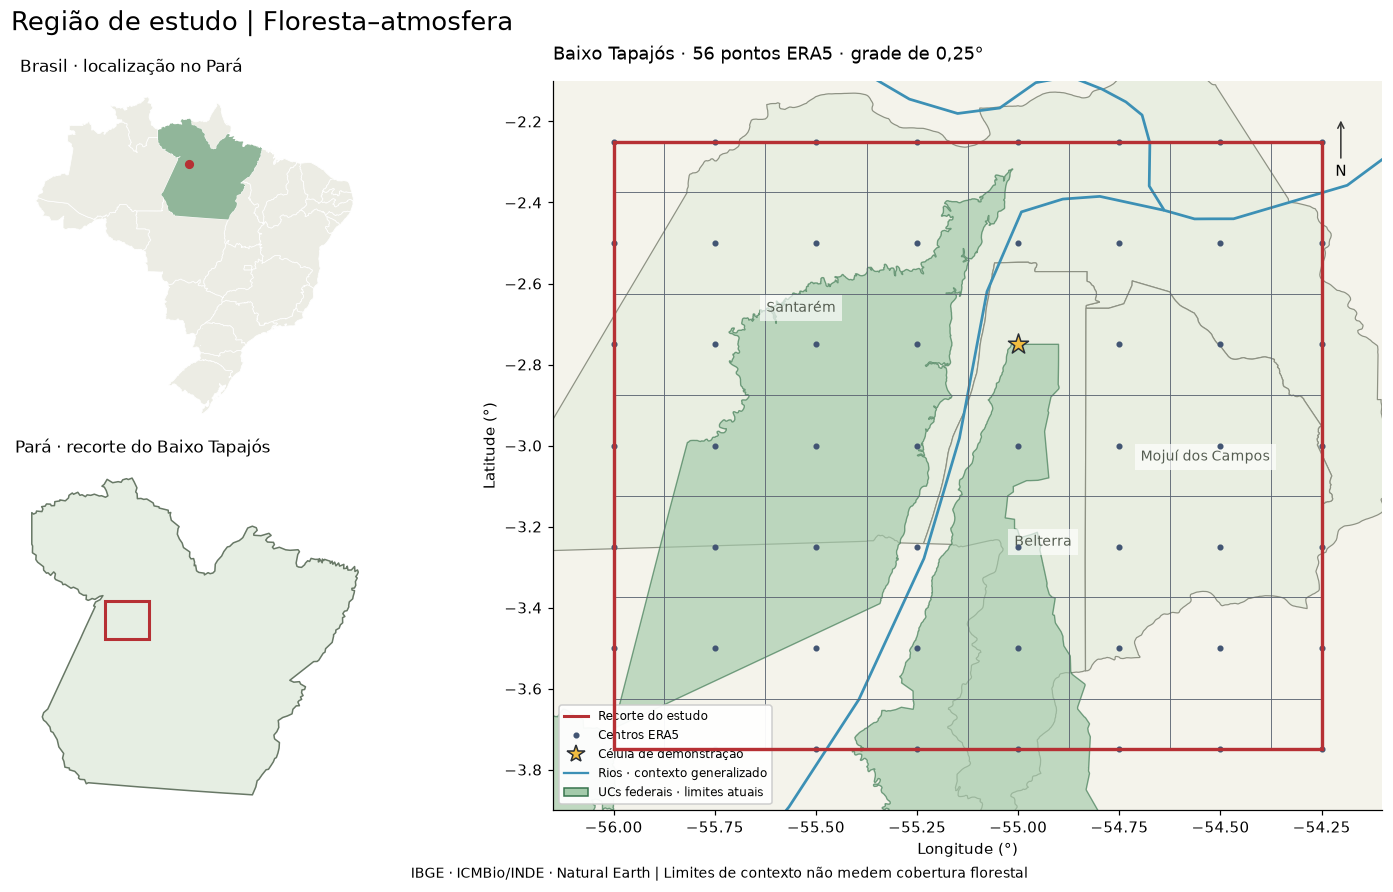

,cell_id,latitude,longitude,edge_fraction,area_km2
0,ERA5_-002.25_-0056.00,-2.25,-56.00,0.25,192.177
1,ERA5_-002.25_-0055.75,-2.25,-55.75,0.50,384.354
2,ERA5_-002.25_-0055.50,-2.25,-55.50,0.50,384.354
3,ERA5_-002.25_-0055.25,-2.25,-55.25,0.50,384.354
4,ERA5_-002.25_-0055.00,-2.25,-55.00,0.50,384.354
5,ERA5_-002.25_-0054.75,-2.25,-54.75,0.50,384.354
6,ERA5_-002.25_-0054.50,-2.25,-54.50,0.50,384.354
7,ERA5_-002.25_-0054.25,-2.25,-54.25,0.25,192.177


A caixa tem aproximadamente **32,267 km²**, incluindo terra e água. Os polígonos das bordas são recortados à caixa.

In [2]:
fig, grid = plot_region(CFG, CONTEXT)
for extension in ['png', 'pdf']:
    fig.savefig(FIGURES / f'01_regiao_grade.{extension}', dpi=180, bbox_inches='tight')
plt.show()
display(GRID[['cell_id', 'latitude', 'longitude', 'edge_fraction', 'area_km2']].head(8).round(3))
display(Markdown(f'A caixa tem aproximadamente **{GRID.area_km2.sum():,.0f} km²**, '
                 'incluindo terra e água. Os polígonos das bordas são recortados à caixa.'))

In [3]:
if 'ucs' in CONTEXT:
    uc_table = CONTEXT['ucs'].drop(columns='geometry')
    display(uc_table)
sources_path = ROOT / 'data/external/tapajos/sources.json'
if sources_path.exists():
    sources = pd.DataFrame(json.loads(sources_path.read_text()))
    display(sources[[c for c in ['name', 'label', 'status', 'features', 'retrieved_utc']
                     if c in sources.columns]])

,ogc_fid,id,nomeuc,cnuc,criacaoano,areahaalb,perimm,criacaoato,esferaadm,grupouc,...,gregional,fusoabrang,demarcacao,escalauc,bioma_pred,cat_iucn,uf,categoria_,sigla_cate,dominio
0,23,1874,RESERVA EXTRATIVISTA TAPAJÓS-ARAPIUNS,0000.00.0259,1998,6.773175e+05,6.010216e+05,"DEC S/N, de 06/11/1998",Federal,US,...,GR1 Norte,21S,Não demarcada,1:250.000,Amazônia,Category VI,PA,Reserva Extrativista,RESEX,Público
1,161,1981,PARQUE NACIONAL DA AMAZÔNIA,0000.00.0136,1974,1.066289e+06,1.803072e+06,"DEC 73.683, DE 19/02/1974; DEC 90.823, DE 18/0...",Federal,PI,...,GR1 Norte,21S,Não demarcada,1:100.000,Amazônia,Category II,AM/PA,Parque Nacional,PARNA,Público
2,168,2081,FLORESTA NACIONAL DE SARACÁ-TAQUERA,0000.00.0109,1989,4.394520e+05,4.826952e+05,"DEC 98.704, de 27/12/1989",Federal,US,...,GR1 Norte,21S,Não demarcada,1:25.000,Amazônia,Category VI,PA,Floresta Nacional,FLONA,Público
3,190,1817,FLORESTA NACIONAL DO TAPAJÓS,0000.00.0123,1974,5.250561e+05,4.816198e+05,"DEC 73.684 de 19/02/1974; LEI 12.678, de 25/0...",Federal,US,...,GR1 Norte,21S,Não demarcada,1:100.000,Amazônia,Category VI,PA,Floresta Nacional,FLONA,Público


,name,label,status,features,retrieved_utc
0,municipio_1506807,Santarém,ok,1,2026-09-08T16:01:04.971133+00:00
1,municipio_1501451,Belterra,ok,1,2026-09-08T16:01:05.144638+00:00
2,municipio_1504752,Mojuí dos Campos,ok,1,2026-09-08T16:01:05.298899+00:00
3,rios,"Natural Earth 1:50m — contexto, não máscara de...",ok,2,2026-09-08T16:00:13.113069+00:00
4,ucs,ICMBio/INDE — limites consultados em 2026; con...,ok,4,2026-09-08T16:00:15.482251+00:00


## 2. O que será baixado e por quê?

| Campo ERA5 original | Unidade original | O que calculamos |
| --- | --- | --- |
| Temperatura a 2 m (`t2m`) | kelvin | Temperatura em °C |
| Ponto de orvalho a 2 m (`d2m`) | kelvin | Umidade relativa e VPD, junto com a temperatura |
| Pressão na superfície (`sp`) | Pa | Umidade específica, junto com o ponto de orvalho |
| Vento zonal a 10 m (`u10`) | m/s | Componente oeste–leste e velocidade |
| Vento meridional a 10 m (`v10`) | m/s | Componente sul–norte e velocidade |
| Precipitação total (`tp`) | m de água | Precipitação em mm na hora terminada no timestamp |

VPD e umidades são variáveis derivadas: não exigem três downloads adicionais.
Temperatura, umidade relativa e VPD compartilham informação e não constituem evidências independentes.

O plano separa variáveis instantâneas de precipitação e divide o intervalo por mês.
Para fechar 31 de janeiro em UTC−03, precisamos também das primeiras horas de 1 de fevereiro UTC.
Este piloto solicita esse dia UTC completo, mas utiliza apenas as horas necessárias nas estatísticas.

In [4]:
jobs = plan_requests(CFG, START, END)
request_table = pd.DataFrame([{
    'mês_UTC': j['month'], 'grupo': j['group'], 'dias_UTC': len(j['request']['day']),
    'horas': len(j['request']['day']) * 24, 'variáveis': len(j['request']['variable']),
    'identificador': j['key'],
} for j in jobs])
display(request_table)
field_values = sum(row['horas'] * row['variáveis'] * len(GRID)
                   for row in request_table.to_dict('records'))
display(Markdown(f'**Estimativa numérica:** {field_values:,} valores; '
                 f'{field_values * 4 / 2**20:.2f} MiB se cada valor ocupar 4 bytes. '
                 'Essa conta exclui metadados, compressão e derivados; não é o tamanho final do download.'))

,mês_UTC,grupo,dias_UTC,horas,variáveis,identificador
0,2024-01,instant,31,744,5,9ceae4f92db3145637d6
1,2024-01,accum,31,744,1,7c7cd49d0fb0aba052b6
2,2024-02,instant,1,24,5,ebf75339ae92cff1459e
3,2024-02,accum,1,24,1,022afda1d7a29c5d9484


**Estimativa numérica:** 258,048 valores; 0.98 MiB se cada valor ocupar 4 bytes. Essa conta exclui metadados, compressão e derivados; não é o tamanho final do download.

### Aquisição explícita pelo terminal

Na raiz do projeto, o primeiro comando apenas mostra as requisições. O segundo acessa o CDS;
o terceiro processa os arquivos locais. É necessário ter credencial CDS configurada e
ter aceitado os termos do conjunto de dados na página do provedor.

```bash
uv run python -m amazon_chaos.pilot_cli plan 2024-01-01 2024-01-31
uv run python -m amazon_chaos.pilot_cli download 2024-01-01 2024-01-31
uv run python -m amazon_chaos.pilot_cli process 2024-01-01 2024-01-31
```

Cada requisição tem seu próprio diretório e manifesto. Na retomada, o programa verifica
o checksum e a correspondência de tempo, grade, variáveis e unidades antes de reutilizar o arquivo.
Um arquivo parcial não conta como download concluído.

In [5]:
inventory = []
for job in jobs:
    folder = job_directory(CFG, job)
    path = folder / 'manifest.json'
    if path.exists():
        manifest = json.loads(path.read_text())
        for item in manifest['files']:
            inventory.append({'mês': job['month'], 'grupo': job['group'],
                              'arquivo': item['name'], 'MiB': item['size_bytes'] / 2**20,
                              'horas': manifest['quality']['n_hours'],
                              'células': manifest['quality']['n_cells']})
    else:
        inventory.append({'mês': job['month'], 'grupo': job['group'], 'arquivo': 'PENDENTE'})
inventory = pd.DataFrame(inventory)
display(inventory.round(3))
raw = None
try:
    raw = open_downloaded(CFG, START, END)
except FileNotFoundError as error:
    display(Markdown(f'**Dados ainda não disponíveis para este intervalo.** {error}'))
if raw is not None:
    display(Markdown(f'**NetCDF validados:** {inventory.MiB.sum():.3f} MiB.'))

,mês,grupo,arquivo,MiB,horas,células
0,2024-01,instant,fields.nc,0.501,744,56
1,2024-01,accum,fields.nc,0.127,744,56
2,2024-02,instant,fields.nc,0.073,24,56
3,2024-02,accum,fields.nc,0.027,24,56


**NetCDF validados:** 0.728 MiB.

## 3. O cubo: tempo × latitude × longitude

Uma variável é um array: `temperatura[t, i, j]` guarda um valor para uma hora e um ponto da grade.
Latitude e longitude são as coordenadas dos índices `i` e `j`. O conjunto `Dataset` contém
vários arrays com essas mesmas coordenadas: temperatura, pressão, vento etc.

Cada quadradinho tem sua própria série temporal. Quando colorimos um mapa pela **média do mês**,
cada cor resume muitas horas daquele quadradinho; o mapa não mostra todos esses valores separadamente.
O cubo bruto inclui horas de apoio. O cubo diário contém somente as datas locais do teste.

In [6]:
if raw is not None:
    display(raw)
    hourly = derive_hourly(raw)
    daily = daily_statistics(hourly, START, END, OFFSET)
    latitudes = raw.latitude.values
    longitudes = raw.longitude.values
    display(Markdown(f'**Forma do array horário:** `{raw.t2m.transpose("time", "latitude", "longitude").shape}`. '
                     f'**Forma do array diário:** `{daily.t2m_c_mean.shape}`. '
                     'O primeiro eixo é tempo; o segundo, latitude; o terceiro, longitude.'))
    lat, lon = CFG['spatial']['pilot_point']
    point_hourly = hourly.sel(latitude=lat, longitude=lon, method='nearest')
    point_daily = daily.sel(latitude=lat, longitude=lon, method='nearest')
    point_label = f'{float(point_daily.latitude):.2f}°, {float(point_daily.longitude):.2f}°'
    display(Markdown(f'**Célula de demonstração:** {point_label}. Seleção geográfica, sem usar o resultado climático.'))

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 768, latitude: 7, longitude: 8)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2024-01-01 ... 2024-02-01T23:00:00
  * latitude   (latitude) float64 56B -2.25 -2.5 -2.75 -3.0 -3.25 -3.5 -3.75
  * longitude  (longitude) float64 64B -56.0 -55.75 -55.5 ... -54.5 -54.25
Data variables:
    t2m        (time, latitude, longitude) float32 172kB 300.2 300.1 ... 299.3
    d2m        (time, latitude, longitude) float32 172kB 296.9 297.3 ... 297.5
    sp         (time, latitude, longitude) float32 172kB 1.005e+05 ... 9.921e+04
    u10        (time, latitude, longitude) float32 172kB -1.086 ... -0.6768
    v10        (time, latitude, longitude) float32 172kB -0.2484 ... -0.3204
    tp         (time, latitude, longitude) float32 172kB 0.0 0.0 ... 0.0003371
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-08T16:03 GRIB to CDM+CF via cfgrib-0.9.1...

**Forma do array horário:** `(768, 7, 8)`. **Forma do array diário:** `(31, 7, 8)`. O primeiro eixo é tempo; o segundo, latitude; o terceiro, longitude.

**Célula de demonstração:** -2.75°, -55.00°. Seleção geográfica, sem usar o resultado climático.

## 4. Qualidade: completude antes da interpretação

O validador verifica as horas esperadas, duplicações, coordenadas e unidades dos arquivos originais.
Depois, cada variável diária ganha uma contagem de horas finitas por célula. Só calculamos sua
estatística quando há **24 horas válidas**. Assim, um dia sem dados não vira um dia sem chuva.

Umidade fisicamente suspeita e precipitação negativa são sinalizadas no processamento,
preservando os valores originais nos arquivos brutos. A tabela abaixo revela perdas de completude.

,variável,células_dias,dias_completos,dias_incompletos,menor_contagem
0,t2m_c,1736,1736,0,24
1,d2m_c,1736,1736,0,24
2,vpd_kpa,1736,1736,0,24
3,rh_pct,1736,1736,0,24
4,q_gkg,1736,1736,0,24
5,wind_speed_10m,1736,1736,0,24
6,u10,1736,1736,0,24
7,v10,1736,1736,0,24
8,surface_pressure_hpa,1736,1736,0,24
9,precip_mm,1736,1736,0,24


**Amostras sinalizadas por umidade:** 0. **Precipitação negativa no bruto:** 0.

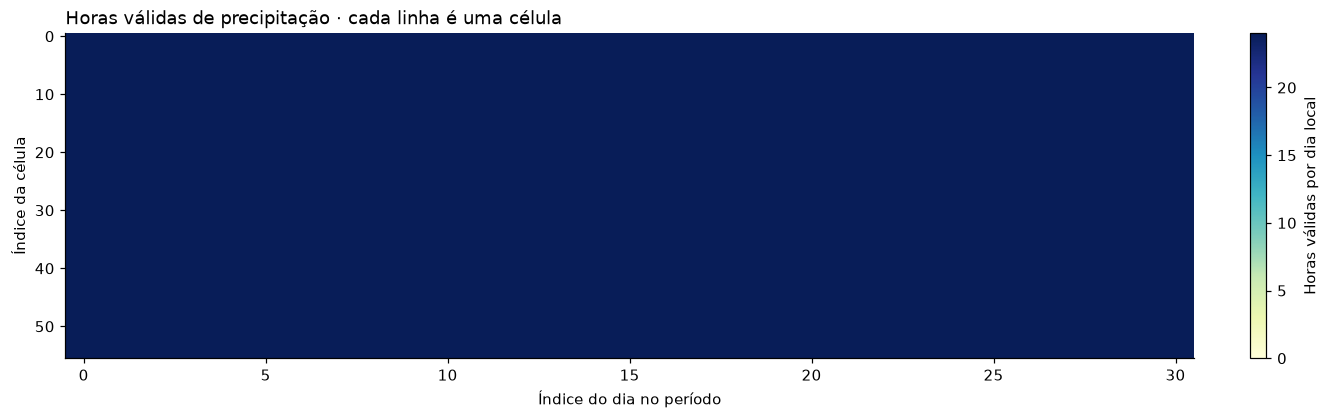

In [7]:
if raw is not None:
    qc = pd.DataFrame([{
        'variável': v.removesuffix('_n_hours'),
        'células_dias': daily[v].size,
        'dias_completos': int((daily[v] == 24).sum()),
        'dias_incompletos': int((daily[v] != 24).sum()),
        'menor_contagem': int(daily[v].min()),
    } for v in daily.data_vars if v.endswith('_n_hours')])
    display(qc)
    display(Markdown(f'**Amostras sinalizadas por umidade:** {int(hourly.humidity_flag.sum())}. '
                     f'**Precipitação negativa no bruto:** {int((raw.tp < 0).sum())}.'))
    completeness = daily.precip_mm_n_hours.stack(cell=('latitude', 'longitude')).transpose('cell', 'time')
    fig, ax = plt.subplots(figsize=(12, 3.7), layout='constrained')
    im = ax.imshow(completeness, aspect='auto', vmin=0, vmax=24, cmap='YlGnBu', interpolation='nearest')
    ax.set(title='Horas válidas de precipitação · cada linha é uma célula',
           xlabel='Índice do dia no período', ylabel='Índice da célula')
    fig.colorbar(im, ax=ax, label='Horas válidas por dia local')
    fig.savefig(FIGURES / '02_completude.png', dpi=180)
    plt.show()

## 5. Da hora ao dia: um exemplo que podemos conferir

Temperatura: subtraímos 273,15 para converter kelvin em °C.
Velocidade: calculamos `sqrt(u10² + v10²)` a cada hora, antes de tirar a média.
VPD: diferença entre a pressão de vapor de saturação na temperatura do ar e a pressão
de vapor estimada pelo ponto de orvalho. Usamos a aproximação de Tetens sobre água
líquida, apropriada ao domínio quente deste piloto; não é uma fórmula geral para gelo.

Para 1 de janeiro local, as temperaturas de 03 UTC de 1/jan a 02 UTC de 2/jan formam
as 24 amostras. A chuva usa os intervalos terminados de 04 UTC de 1/jan a 03 UTC de 2/jan.
Essa diferença de uma hora decorre de a chuva representar um **intervalo**, enquanto a
temperatura é uma amostra instantânea. Os máximos são máximos das amostras horárias;
o máximo do vento não é uma rajada.

,t2m_c,rh_pct,vpd_kpa,wind_speed_10m
time,,,,
2024-01-01 00:00:00,27.629000,78.405998,0.799,1.650
2024-01-01 01:00:00,27.458000,79.249001,0.760,2.186
2024-01-01 02:00:00,27.184000,80.702003,0.696,2.666
2024-01-01 03:00:00,26.875999,82.667000,0.614,2.925
2024-01-01 04:00:00,26.635000,83.362000,0.581,2.963
2024-01-01 05:00:00,26.517000,83.702003,0.565,2.861
2024-01-01 06:00:00,26.198999,84.488998,0.528,2.863
2024-01-01 07:00:00,26.594000,83.216003,0.584,3.466


,t2m_c_mean,t2m_c_min,t2m_c_max,precip_mm_sum,latitude,longitude
time,,,,,,
2024-01-01,28.719999,26.198999,31.174999,0.41,-2.75,-55.0


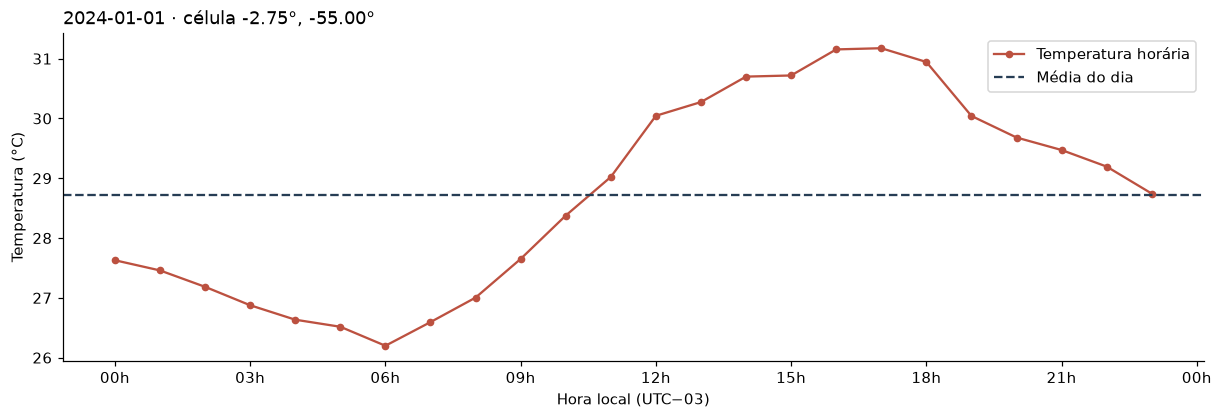

In [8]:
if raw is not None:
    local_times = point_hourly.time + np.timedelta64(OFFSET, 'h')
    point_local = point_hourly.assign_coords(time=local_times)
    example = point_local[['t2m_c', 'rh_pct', 'vpd_kpa', 'wind_speed_10m']].sel(time=START)
    display(example.to_dataframe().drop(columns=['latitude', 'longitude'], errors='ignore').head(8).round(3))
    display(point_daily[['t2m_c_mean', 't2m_c_min', 't2m_c_max', 'precip_mm_sum']]
            .sel(time=[START]).to_dataframe().round(3))
    fig, ax = plt.subplots(figsize=(11, 3.7), layout='constrained')
    ax.plot(example.time, example.t2m_c, 'o-', color='#bc5140', ms=4, label='Temperatura horária')
    ax.axhline(float(point_daily.t2m_c_mean.sel(time=START)), color='#263d54', ls='--', label='Média do dia')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Hh'))
    ax.set(title=f'{START} · célula {point_label}', xlabel='Hora local (UTC−03)', ylabel='Temperatura (°C)')
    ax.legend()
    fig.savefig(FIGURES / '03_hora_para_dia.png', dpi=180)
    plt.show()

## 6. As séries diárias, lado a lado

O primeiro painel mostra média e faixa mínimo–máximo de temperatura. Os demais apresentam
umidade relativa, VPD, vento, chuva e umidade específica na mesma célula e no mesmo calendário.
O alinhamento permite identificar episódios coincidentes, sem transformar coincidência em causalidade.

A precipitação é total por dia; as demais linhas são médias diárias. Janeiro sozinho
não permite calcular uma climatologia anual, tendência histórica ou relação com desmatamento.

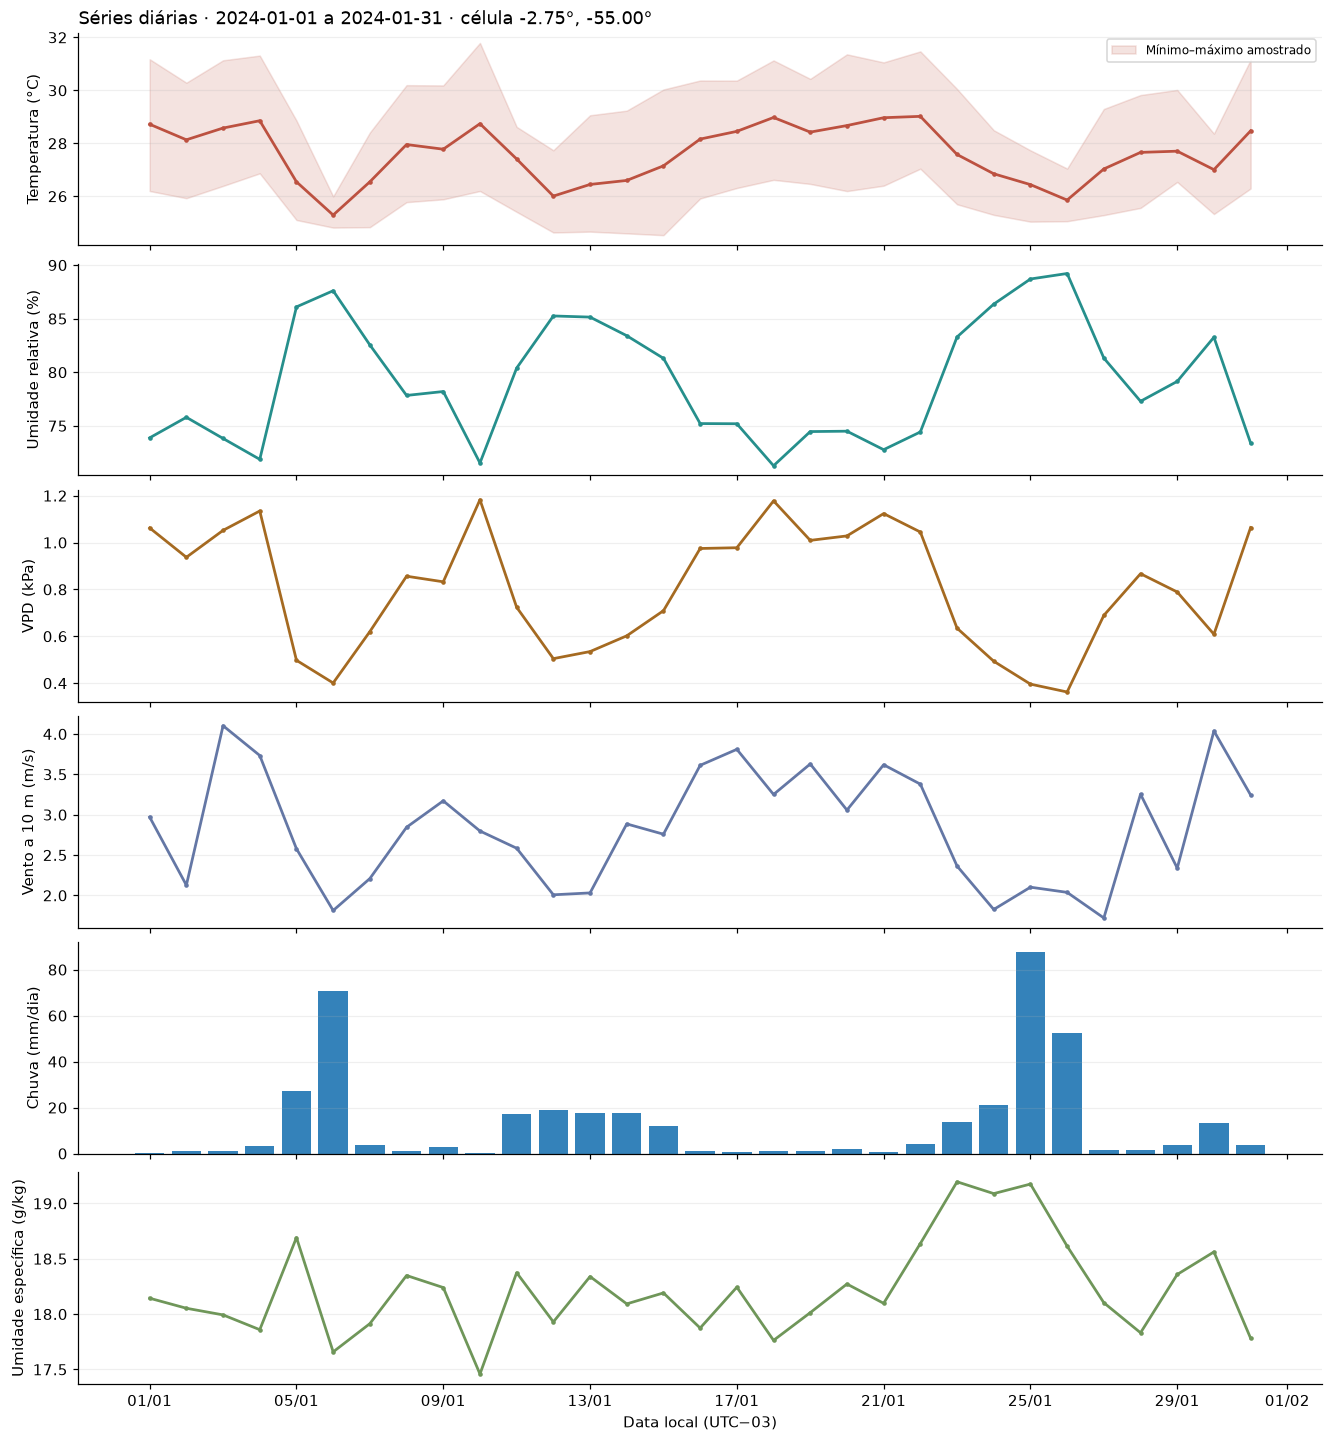

In [9]:
if raw is not None:
    panels = [
        ('t2m_c_mean', 'Temperatura (°C)', '#bc5140'),
        ('rh_pct_mean', 'Umidade relativa (%)', '#268f8c'),
        ('vpd_kpa_mean', 'VPD (kPa)', '#a56a21'),
        ('wind_speed_10m_mean', 'Vento a 10 m (m/s)', '#6477a5'),
        ('precip_mm_sum', 'Chuva (mm/dia)', '#3482ba'),
        ('q_gkg_mean', 'Umidade específica (g/kg)', '#6f9659'),
    ]
    fig, axes = plt.subplots(6, 1, figsize=(12, 13), sharex=True, layout='constrained')
    for ax, (var, label, color) in zip(axes, panels):
        values = point_daily[var]
        if var == 'precip_mm_sum':
            ax.bar(point_daily.time.values, values, color=color, width=.8)
        else:
            ax.plot(point_daily.time, values, color=color, lw=1.8, marker='.', ms=4)
        ax.set_ylabel(label)
        ax.grid(axis='y', alpha=.2)
    axes[0].fill_between(point_daily.time.values, point_daily.t2m_c_min.values,
                         point_daily.t2m_c_max.values, color='#bc5140', alpha=.16,
                         label='Mínimo–máximo amostrado')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_title(f'Séries diárias · {START} a {END} · célula {point_label}')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    axes[-1].set_xlabel('Data local (UTC−03)')
    for extension in ['png', 'pdf']:
        fig.savefig(FIGURES / f'04_series_diarias.{extension}', dpi=180, bbox_inches='tight')
    plt.show()

## 7. A estrela e a região inteira são diferentes resumos

A média regional abaixo usa a área de cada polígono de integração como peso. As células
de borda representam áreas menores dentro da caixa. Neste piloto, o peso inclui terra
e água: ainda não temos a máscara detalhada de cobertura para calcular médias apenas terrestres.

O espalhamento entre células descreve heterogeneidade espacial; não é um intervalo
de confiança e não transforma 56 células vizinhas em 56 observações independentes.

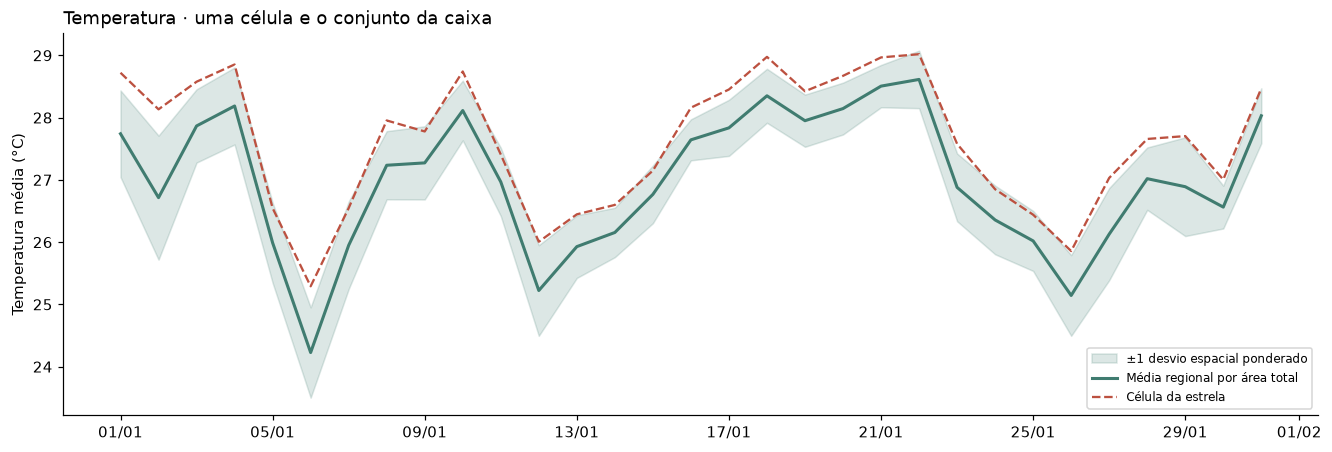

In [10]:
if raw is not None:
    weight_table = GRID.pivot(index='latitude', columns='longitude', values='area_km2')
    weights = xr.DataArray(weight_table.values, coords={'latitude': weight_table.index.values,
                           'longitude': weight_table.columns.values}, dims=('latitude', 'longitude'))
    weights = weights.sel(latitude=daily.latitude, longitude=daily.longitude)
    regional = daily.t2m_c_mean.weighted(weights).mean(('latitude', 'longitude'))
    spatial_sd = daily.t2m_c_mean.weighted(weights).std(('latitude', 'longitude'))
    fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
    ax.fill_between(daily.time.values, (regional-spatial_sd).values, (regional+spatial_sd).values,
                    alpha=.18, color='#407c70', label='±1 desvio espacial ponderado')
    ax.plot(daily.time, regional, color='#407c70', lw=2, label='Média regional por área total')
    ax.plot(daily.time, point_daily.t2m_c_mean, color='#bc5140', ls='--', label='Célula da estrela')
    ax.set(title='Temperatura · uma célula e o conjunto da caixa', ylabel='Temperatura média (°C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.legend(fontsize=8)
    fig.savefig(FIGURES / '05_celula_regiao.png', dpi=180)
    plt.show()

## 8. Como o clima varia no espaço durante este mês?

Nos mapas abaixo, temperatura, VPD e vento são médias dos dias completos do período.
A chuva é o total do período, calculado somente onde todos os dias estão completos.
Cada cor corresponde ao mesmo polígono ERA5 do primeiro mapa. As escalas e unidades
são diferentes entre painéis: cores parecidas não significam valores equivalentes.

Os mapas continuam incluindo células com água. A cobertura florestal e o histórico
de fogo serão incorporados depois, antes de comparar gradientes de perturbação.

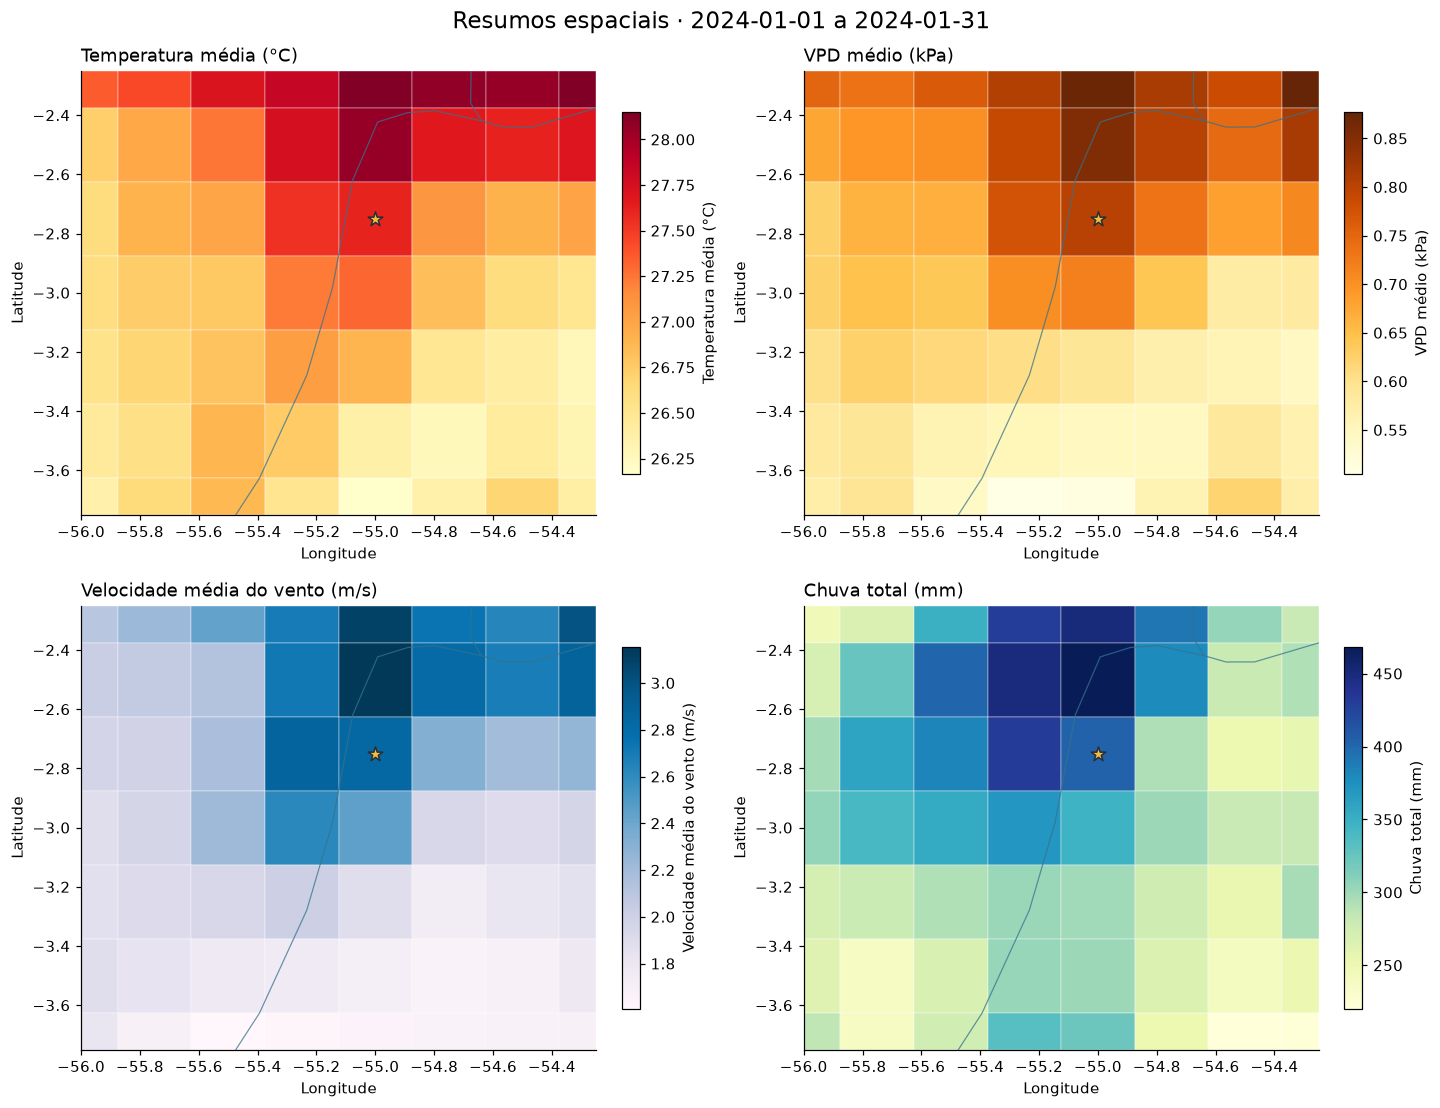

In [11]:
if raw is not None:
    summaries = [
        (daily.t2m_c_mean.mean('time'), 'Temperatura média (°C)', 'YlOrRd'),
        (daily.vpd_kpa_mean.mean('time'), 'VPD médio (kPa)', 'YlOrBr'),
        (daily.wind_speed_10m_mean.mean('time'), 'Velocidade média do vento (m/s)', 'PuBu'),
        (daily.precip_mm_sum.sum('time', min_count=daily.sizes['time']), 'Chuva total (mm)', 'YlGnBu'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), layout='constrained')
    for ax, (field, title, cmap) in zip(axes.flat, summaries):
        table = field.rename('value').to_dataframe().reset_index()
        mapped = GRID.merge(table[['latitude', 'longitude', 'value']], on=['latitude', 'longitude'])
        mapped.plot(column='value', ax=ax, cmap=cmap, legend=True,
                    legend_kwds={'shrink': .75, 'label': title}, edgecolor='white', linewidth=.25,
                    missing_kwds={'color': '#cccccc', 'label': 'Incompleto'})
        if 'rios' in CONTEXT:
            CONTEXT['rios'].plot(ax=ax, color='#34738d', linewidth=.8, alpha=.75)
        n, w, s, e = CFG['spatial']['area']
        ax.set(xlim=(w, e), ylim=(s, n), title=title, xlabel='Longitude', ylabel='Latitude')
        ax.scatter(float(point_daily.longitude), float(point_daily.latitude), marker='*',
                   s=100, c='#f2bd40', edgecolor='#292e35', zorder=5)
    fig.suptitle(f'Resumos espaciais · {START} a {END}', fontsize=15)
    for extension in ['png', 'pdf']:
        fig.savefig(FIGURES / f'06_mapas_clima.{extension}', dpi=180, bbox_inches='tight')
    plt.show()

## 9. Resumo numérico e leitura dos resultados

A tabela contém resumos da célula de demonstração. Compare o intervalo diário
de temperatura com a amplitude horária mostrada antes: são perguntas diferentes.
O vento médio descreve as velocidades, não a intensidade de rajadas; a umidade específica
descreve massa de vapor por massa de ar úmido, enquanto a relativa depende também da temperatura.

In [12]:
if raw is not None:
    frame = point_daily[[p[0] for p in panels]].to_dataframe()
    display(frame[[p[0] for p in panels]].describe().round(3))
    temp_mean = float(point_daily.t2m_c_mean.mean())
    complete_rain = int(point_daily.precip_mm_sum.count()) == point_daily.sizes['time']
    rain_total = float(point_daily.precip_mm_sum.sum()) if complete_rain else np.nan
    display(Markdown(f'Na célula **{point_label}**, a temperatura média do período foi '
                     f'**{temp_mean:.2f} °C**. O acumulado de chuva nos dias locais foi '
                     f'**{rain_total:.1f} mm**. Esses números são calculados dos arquivos acima; '
                     'não caracterizam por si só o clima de longo prazo.'))
    output = ROOT / 'data/processed' / CFG['experiment_id']
    output.mkdir(parents=True, exist_ok=True)
    daily.attrs['request_keys'] = ','.join(j['key'] for j in jobs)
    daily.to_netcdf(output / f'daily_{START}_{END}.nc')
    frame.to_csv(output / f'point_daily_{START}_{END}.csv', index=True)
    qc.to_csv(output / f'quality_{START}_{END}.csv', index=False)
    display(Markdown(f'Derivados salvos em `{output.relative_to(ROOT)}`; '
                     f'figuras em `{FIGURES.relative_to(ROOT)}`.'))

,t2m_c_mean,rh_pct_mean,vpd_kpa_mean,wind_speed_10m_mean,precip_mm_sum,q_gkg_mean
count,31.000,31.000,31.000,31.000,31.000,31.000
mean,27.613,79.180,0.803,2.835,13.046,18.222
std,1.052,5.566,0.256,0.706,20.962,0.425
min,25.291,71.278,0.362,1.721,0.149,17.459
25%,26.724,74.447,0.605,2.168,1.193,17.922
50%,27.703,78.204,0.832,2.845,3.683,18.143
75%,28.524,83.353,1.037,3.316,17.257,18.366
max,29.018,89.217,1.183,4.103,87.608,19.195


Na célula **-2.75°, -55.00°**, a temperatura média do período foi **27.61 °C**. O acumulado de chuva nos dias locais foi **404.4 mm**. Esses números são calculados dos arquivos acima; não caracterizam por si só o clima de longo prazo.

Derivados salvos em `data/processed/tapajos-era5-2024`; figuras em `reports/figures/tapajos_2024`.

## 10. O que vem depois deste teste

- Completar os meses de 2024 para observar a sazonalidade dentro do ano.
- Integrar MapBiomas Cobertura e Fogo, PRODES e registros de focos, com histórico de apoio.
- Calcular área terrestre/água e definir células comparáveis a partir de dados de paisagem.
- Expandir para 2001–2024; produzir climatologia e anomalias somente com uma referência definida.
- Aplicar os métodos do laboratório sintético depois de verificar adequação, amostragem e robustez.

O PRODES geográfico anterior a 2008 está agregado no TerraBrasilis; não criaremos uma
série anual por célula para esses anos a partir do acumulado. A reanálise ERA5 usa
representação de uso do solo sem evolução anual: diferenças climáticas associadas à
perturbação não serão interpretadas automaticamente como seu efeito local direto.

### Fontes e documentação

- [ERA5 — conjunto horário](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview)
- [ECMWF — semântica dos dados e acumulações](https://confluence.ecmwf.int/spaces/CKB/pages/76414402/ERA5+data+documentation)
- [ECMWF — representação da superfície](https://confluence.ecmwf.int/spaces/GCR/pages/473842427/ECMWF%2BERA5)
- [IBGE — API de malhas simplificadas](https://servicodados.ibge.gov.br/api/docs/malhas?versao=3)
- [ICMBio — dados geoespaciais](https://www.gov.br/icmbio/pt-br/dados-icmbio/dados_geoespaciais)
- [Natural Earth — rios](https://github.com/nvkelso/natural-earth-vector/blob/master/geojson/ne_50m_rivers_lake_centerlines.geojson)
- [TerraBrasilis — disponibilidade histórica PRODES](https://terrabrasilis.dpi.inpe.br/faq/)
- Desenho metodológico local: `docs/DESENHO_ESTUDO_2001_2024.md`.

As respostas das fontes cartográficas e as requisições ERA5 têm URLs, datas e checksums
registrados junto aos arquivos. Os valores originais permanecem em `data/raw`.